# LSTM - Long Short-Term Memory (PyTorch)

A plain [`RNN`](../06_RNN) struggles to remember information over long sequences
(vanishing gradients). An LSTM fixes this with a **cell state** plus three gates
(input, forget, output) that learn what to keep, what to discard, and what to expose
at each step — letting gradients flow over much longer sequences.

Same task and pipeline as `06_RNN` — newsgroup posts, **hockey vs. space**
(`sklearn.datasets.fetch_20newsgroups`) — only the recurrent layer changes,
from `nn.RNN` to `nn.LSTM`.

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                           remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = torch.tensor([encode(t) for t in train_tokens], dtype=torch.long)
X_test = torch.tensor([encode(t) for t in test_tokens], dtype=torch.long)
# real (non-padding) length of every sequence, clamped to at least 1
lengths_train = torch.tensor([max(1, min(len(t), MAX_LEN)) for t in train_tokens], dtype=torch.long)
lengths_test = torch.tensor([max(1, min(len(t), MAX_LEN)) for t in test_tokens], dtype=torch.long)
y_train = torch.tensor(train.target, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test.target, dtype=torch.float32).view(-1, 1)

vocab_size = len(vocab)
X_train.shape, vocab_size

(torch.Size([1193, 150]), 5000)

In [3]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # (batch, seq_len, emb_dim)
        # Most posts are far shorter than MAX_LEN; pack_padded_sequence tells the LSTM
        # each sequence's real length so it stops recurring there instead of running
        # on through dozens of padding steps and diluting the final hidden state.
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, cell) = self.lstm(packed)  # hidden: (1, batch, hidden_dim) at the real last step
        return self.fc(hidden.squeeze(0))      # (batch, 1) logits


model = LSTMClassifier(vocab_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [4]:
losses = []
for epoch in range(30):
    optimizer.zero_grad()
    logits = model(X_train, lengths_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f"epoch {epoch+1:2d}  loss {loss.item():.4f}")

epoch  1  loss 0.6963


epoch  2  loss 0.6866


epoch  3  loss 0.6772


epoch  4  loss 0.6666


epoch  5  loss 0.6535


...

epoch 26  loss 0.0935


epoch 27  loss 0.0875


epoch 28  loss 0.0828


epoch 29  loss 0.0748


epoch 30  loss 0.0647


Test accuracy: 0.844


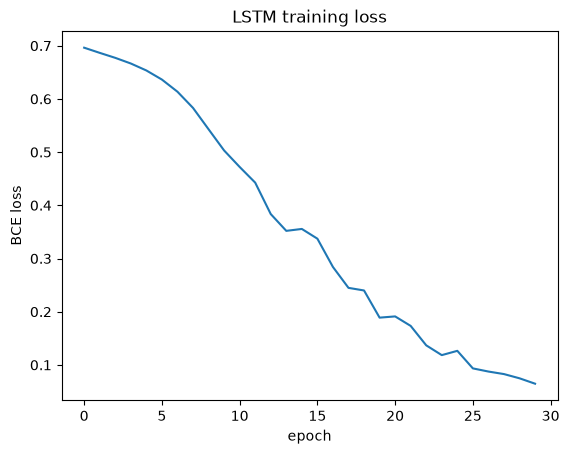

In [5]:
with torch.no_grad():
    preds = torch.sigmoid(model(X_test, lengths_test)) >= 0.5
    accuracy = (preds.float() == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("LSTM training loss")
plt.show()